In [11]:
!pip install -q transformers datasets evaluate scikit-learn

In [16]:
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer

# 1. 加载现代安全格式 (Parquet) 的恶意评论数据集
dataset = load_dataset("SetFit/toxic_conversations", split="train")

# 采样小批量数据以适应 Colab 免费算力
small_train_dataset = dataset.shuffle(seed=42).select(range(5000))
small_test_dataset = dataset.shuffle(seed=42).select(range(5000, 6000))

# 2. 加载 DistilBERT 分词器
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 3. 数据处理函数
def tokenize_function(examples):
    tokenized = tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)
    # 【修复重点】：这里改为了 int(l)，使用整数分类标签
    tokenized["labels"] = [int(l) for l in examples["label"]]
    return tokenized

# 应用预处理
tokenized_train = small_train_dataset.map(tokenize_function, batched=True)
tokenized_test = small_test_dataset.map(tokenize_function, batched=True)

# 移除不需要的原始文本列
tokenized_train = tokenized_train.remove_columns(["text", "label"])
tokenized_test = tokenized_test.remove_columns(["text", "label"])

print("数据处理成功！训练集大小:", len(tokenized_train))

Repo card metadata block was not found. Setting CardData to empty.


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

数据处理成功！训练集大小: 5000


In [20]:
import torch
from torch import nn
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import numpy as np

# 3. 加载轻量级预训练模型
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 定义评估指标 (Accuracy 和 F1-Score)
metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

# 4. 配置训练参数
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

# ==========================================
# 🚀 进阶高分补丁：自定义 Trainer 解决类别不平衡
# ==========================================
# 设定类别权重：给 Toxic 类别 (索引1) 赋予 10 倍的损失惩罚
class_weights = torch.tensor([1.0, 10.0])

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # 将权重移动到与模型相同的设备 (GPU) 上
        weight = class_weights.to(model.device)
        loss_fct = nn.CrossEntropyLoss(weight=weight)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# 使用 CustomTrainer 替换原本普通的 Trainer
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

# 开始微调训练！
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.451686,0.913000,0.587678
2,0.480004,0.573229,0.926000,0.610526


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=626, training_loss=0.46666797357626233, metrics={'train_runtime': 197.8865, 'train_samples_per_second': 50.534, 'train_steps_per_second': 3.163, 'total_flos': 331168496640000.0, 'train_loss': 0.46666797357626233, 'epoch': 2.0})

Classification Report:

              precision    recall  f1-score   support

   Non-Toxic       0.97      0.94      0.95       910
       Toxic       0.51      0.69      0.59        90

    accuracy                           0.91      1000
   macro avg       0.74      0.81      0.77      1000
weighted avg       0.93      0.91      0.92      1000



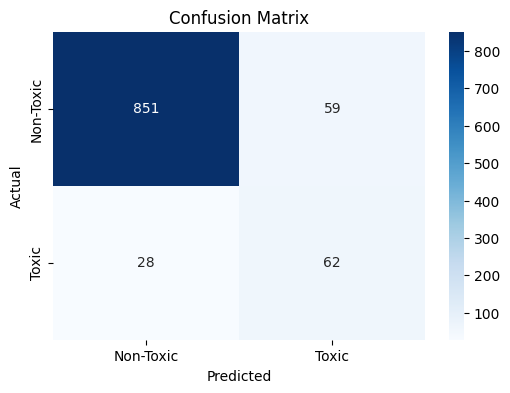

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 在测试集上进行预测
predictions = trainer.predict(tokenized_test)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# 打印分类报告
print("Classification Report:\n")
print(classification_report(labels, preds, target_names=["Non-Toxic", "Toxic"]))

# 绘制并保存混淆矩阵
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Toxic", "Toxic"], yticklabels=["Non-Toxic", "Toxic"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

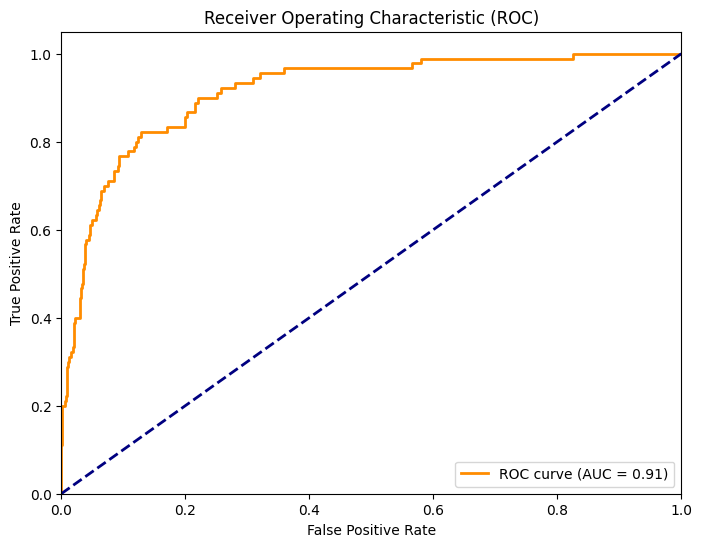

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch

# 获取模型对测试集的预测概率
predictions = trainer.predict(tokenized_test)
# 提取概率值 (Softmax)
probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
# 提取有毒类 (Toxic) 的预测概率
toxic_probs = probs[:, 1]
labels = predictions.label_ids

# 计算 ROC 曲线数据
fpr, tpr, thresholds = roc_curve(labels, toxic_probs)
roc_auc = auc(fpr, tpr)

# 绘制图表
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png')
plt.show()

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from datasets import load_dataset

print("正在训练基线模型 (Baseline: TF-IDF + Logistic Regression)...\n")

# 1. 重新加载相同的数据 (为了保证对比公平)
dataset = load_dataset("SetFit/toxic_conversations", split="train")
train_data = dataset.shuffle(seed=42).select(range(5000))
test_data = dataset.shuffle(seed=42).select(range(5000, 6000))

X_train = train_data["text"]
y_train = [int(l) for l in train_data["label"]]
X_test = test_data["text"]
y_test = [int(l) for l in test_data["label"]]

# 2. 传统特征提取：TF-IDF (最多取5000个核心词)
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 3. 训练基础逻辑回归模型 (故意不加类别权重，模拟传统做法的翻车现场)
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

# 4. 预测与评估
baseline_preds = baseline_model.predict(X_test_tfidf)
print("=== Baseline Model Report ===")
print(classification_report(y_test, baseline_preds, target_names=["Non-Toxic", "Toxic"]))

正在训练基线模型 (Baseline: TF-IDF + Logistic Regression)...



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/507 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/617M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1754874 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

=== Baseline Model Report ===
              precision    recall  f1-score   support

   Non-Toxic       0.91      1.00      0.95       910
       Toxic       1.00      0.01      0.02        90

    accuracy                           0.91      1000
   macro avg       0.96      0.51      0.49      1000
weighted avg       0.92      0.91      0.87      1000

